In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, joblib, warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

In [2]:
df = pd.read_csv("Telecom_churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [5]:
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [6]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Remaining nulls:", df['TotalCharges'].isnull().sum())
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())

Remaining nulls: 0
Duplicate customerIDs: 0


In [7]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [8]:
print(df['Contract'].value_counts(normalize=True) * 100)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [9]:
churn_financials = df.groupby('Churn')[['tenure', 'MonthlyCharges']].mean()
churn_financials

,tenure,MonthlyCharges
Churn,,
No,37.569965,61.265124
Yes,17.979133,74.441332


In [10]:
revenue_lost = df[df['Churn'] == 'Yes']['MonthlyCharges'].sum()
active_revenue = df[df['Churn'] == 'No']['MonthlyCharges'].sum()

print(f"Total Monthly Revenue from Active Users: ${active_revenue:,.2f}")
print(f"Total Monthly Revenue LOST due to Churn: ${revenue_lost:,.2f}")
print(f"Percentage of Revenue Lost: {revenue_lost / (active_revenue + revenue_lost) * 100:.2f}%")

Total Monthly Revenue from Active Users: $316,985.75
Total Monthly Revenue LOST due to Churn: $139,130.85
Percentage of Revenue Lost: 30.50%


In [11]:
print(pd.crosstab(df['Dependents'], df['Churn'], normalize='index') * 100)
pd.crosstab([df['InternetService'], df['TechSupport']], df['Churn'], normalize='index') * 100

Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


Churn                                       No        Yes
InternetService TechSupport                              
DSL             No                   72.244570  27.755430
                Yes                  90.322581   9.677419
Fiber optic     No                   50.627803  49.372197
                Yes                  77.367206  22.632794
No              No internet service  92.595020   7.404980

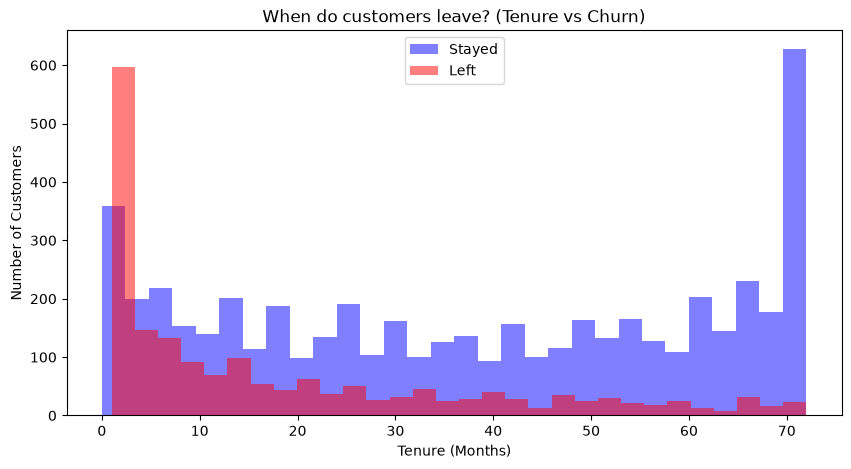

In [12]:
plt.figure(figsize=(10, 5))
df[df['Churn'] == 'No']['tenure'].plot(kind='hist', bins=30, alpha=0.5, color='blue', label='Stayed')
df[df['Churn'] == 'Yes']['tenure'].plot(kind='hist', bins=30, alpha=0.5, color='red', label='Left')
plt.title('When do customers leave? (Tenure vs Churn)')
plt.xlabel('Tenure (Months)'); plt.ylabel('Number of Customers'); plt.legend(); plt.show()

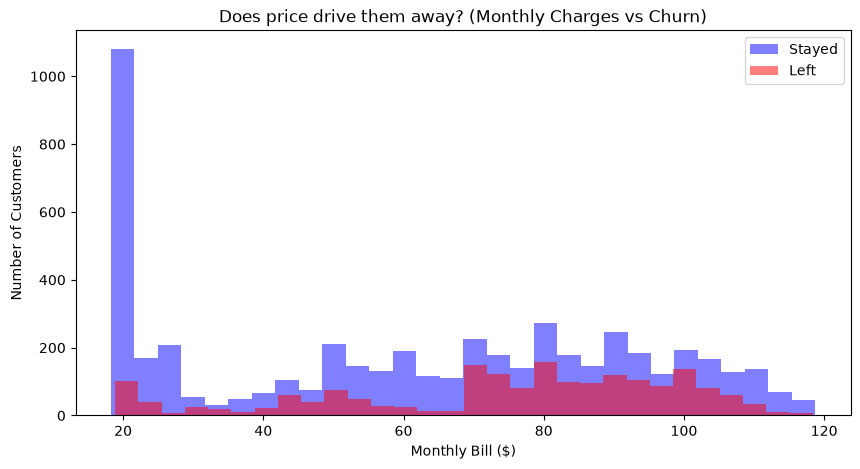

In [13]:
plt.figure(figsize=(10, 5))
df[df['Churn'] == 'No']['MonthlyCharges'].plot(kind='hist', bins=30, alpha=0.5, color='blue', label='Stayed')
df[df['Churn'] == 'Yes']['MonthlyCharges'].plot(kind='hist', bins=30, alpha=0.5, color='red', label='Left')
plt.title('Does price drive them away? (Monthly Charges vs Churn)')
plt.xlabel('Monthly Bill ($)'); plt.ylabel('Number of Customers'); plt.legend(); plt.show()

In [14]:
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-1 Year', '1-2 Years', '2-3 Years', '3-4 Years', '4-5 Years', '5-6 Years']
df['Tenure_Group'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

print("Unassigned rows:", df['Tenure_Group'].isnull().sum())
tenure_churn = pd.crosstab(df['Tenure_Group'], df['Churn'], normalize='index') * 100
tenure_churn

Unassigned rows: 0


Churn,No,Yes
Tenure_Group,,
0-1 Year,52.561757,47.438243
1-2 Years,71.289062,28.710938
2-3 Years,78.365385,21.634615
3-4 Years,80.971129,19.028871
4-5 Years,85.576923,14.423077
5-6 Years,93.390192,6.609808


In [15]:
df.to_csv("Telecom_Churn_Cleaned_For_PowerBI.csv", index=False)

In [16]:
%%writefile features.py
import pandas as pd
import numpy as np

SERVICE_COLS = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

def add_features(X):
    X = X.copy()
    X['NumServices'] = (X[SERVICE_COLS] == 'Yes').sum(axis=1)
    X['IsMonthToMonth'] = (X['Contract'] == 'Month-to-month').astype(int)
    X['AutoPay'] = X['PaymentMethod'].str.contains('automatic', case=False).astype(int)
    X['FiberNoSupport'] = ((X['InternetService'] == 'Fiber optic') & (X['TechSupport'] != 'Yes')).astype(int)
    hist_avg = np.where(X['tenure'] > 0, X['TotalCharges'] / X['tenure'].replace(0, np.nan), X['MonthlyCharges'])
    X['ChargeVsHistory'] = X['MonthlyCharges'] - hist_avg   # current bill vs. historical average
    return X

Overwriting features.py


In [17]:
from sklearn.model_selection import train_test_split

df_ml = df.drop(columns=['customerID', 'Tenure_Group']).copy()
df_ml['Churn'] = (df_ml['Churn'] == 'Yes').astype(int)

X = df_ml.drop(columns='Churn'); y = df_ml['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()
print(X_train.shape, X_test.shape, "| churn rate:", y_train.mean().round(3), y_test.mean().round(3))
print(len(cat_cols), "categorical columns:", cat_cols)

(5634, 19) (1409, 19) | churn rate: 0.265 0.265
15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [18]:
from features import add_features
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from imblearn.pipeline import Pipeline as ImbPipeline

def make_prep():
    return ColumnTransformer([
        ('num', StandardScaler(), make_column_selector(dtype_include=np.number)),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), cat_cols)
    ])

def build(clf, sampler=None):
    steps = [('features', FunctionTransformer(add_features)), ('prep', make_prep())]
    if sampler is not None:
        steps.append(('smote', sampler))
    steps.append(('clf', clf))
    return ImbPipeline(steps)

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

spw = (y_train == 0).sum() / (y_train == 1).sum()
models = {
    'Dummy (majority)':            build(DummyClassifier(strategy='prior')),
    'LogReg (class weight)':       build(LogisticRegression(max_iter=1000, class_weight='balanced')),
    'LogReg + SMOTE':              build(LogisticRegression(max_iter=1000), SMOTE(random_state=42)),
    'RandomForest (class weight)': build(RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)),
    'XGBoost (scale_pos_weight)':  build(XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, scale_pos_weight=spw, eval_metric='logloss', random_state=42)),
    'XGBoost + SMOTE':             build(XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, eval_metric='logloss', random_state=42), SMOTE(random_state=42)),
    'LightGBM (class weight)':     build(LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, class_weight='balanced', random_state=42, verbose=-1)),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'roc_auc': 'roc_auc', 'pr_auc': 'average_precision', 'recall': 'recall', 'precision': 'precision', 'f1': 'f1'}

rows = []
for name, m in models.items():
    s = cross_validate(m, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({'model': name, **{k: s[f'test_{k}'].mean() for k in scoring}})
results = pd.DataFrame(rows).set_index('model').round(3).sort_values('pr_auc', ascending=False)
results

,roc_auc,pr_auc,recall,precision,f1
model,,,,,
LogReg (class weight),0.845,0.658,0.802,0.517,0.629
LogReg + SMOTE,0.844,0.655,0.786,0.524,0.629
XGBoost (scale_pos_weight),0.841,0.654,0.757,0.528,0.622
XGBoost + SMOTE,0.840,0.648,0.609,0.603,0.605
LightGBM (class weight),0.840,0.648,0.746,0.539,0.626
RandomForest (class weight),0.825,0.616,0.475,0.641,0.545
Dummy (majority),0.500,0.265,0.000,0.000,0.000


In [20]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'clf__n_estimators': [200, 300, 400, 600],
    'clf__max_depth': [2, 3, 4, 5, 6],
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'clf__subsample': [0.6, 0.8, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
    'clf__min_child_weight': [1, 3, 5, 10],
    'clf__reg_lambda': [1, 3, 10],
}
search = RandomizedSearchCV(models['XGBoost (scale_pos_weight)'], param_dist, n_iter=30,
                            scoring='average_precision', cv=cv, random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
best_pipe = search.best_estimator_
print(search.best_params_)
print("CV PR-AUC:", round(search.best_score_, 3))

{'clf__subsample': 0.8, 'clf__reg_lambda': 3, 'clf__n_estimators': 300, 'clf__min_child_weight': 3, 'clf__max_depth': 2, 'clf__learning_rate': 0.03, 'clf__colsample_bytree': 0.6}
CV PR-AUC: 0.668


In [21]:
from sklearn.model_selection import cross_val_predict

train_scores = cross_val_predict(best_pipe, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

print("Average predicted churn probability:", round(train_scores.mean(), 3))
print("Actual churn rate:", round(y_train.mean(), 3))

Average predicted churn probability: 0.41
Actual churn rate: 0.265


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

def to_logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)          # avoid dividing by zero
    return np.log(p / (1 - p)).reshape(-1, 1)   # probability -> log-odds

calibrator = LogisticRegression()
calibrator.fit(to_logit(train_scores), y_train)
train_proba = calibrator.predict_proba(to_logit(train_scores))[:, 1]

print("Average probability after fixing:", round(train_proba.mean(), 3))
print("Brier score before:", round(brier_score_loss(y_train, train_scores), 4))
print("Brier score after: ", round(brier_score_loss(y_train, train_proba), 4))

# Check: group customers by predicted risk and compare with the real churn rate
check = pd.DataFrame({'raw': train_scores, 'fixed': train_proba, 'actual': y_train.values})
check['group'] = pd.qcut(check['fixed'], 5, labels=['Lowest', 'Low', 'Middle', 'High', 'Highest'])
check.groupby('group', observed=True)[['raw', 'fixed', 'actual']].mean().round(3)

Average probability after fixing: 0.265
Brier score before: 0.1613
Brier score after:  0.1336


,raw,fixed,actual
group,,,
Lowest,0.045,0.016,0.016
Low,0.157,0.062,0.074
Middle,0.383,0.188,0.178
High,0.629,0.393,0.385
Highest,0.834,0.668,0.674


Best threshold: 0.07 | profit: 297,286
Profit at 0.50: 199,316
Contact everyone: 262,047 | contact no one: 0
Customers contacted: 67.6% | precision: 0.38 | recall: 0.97


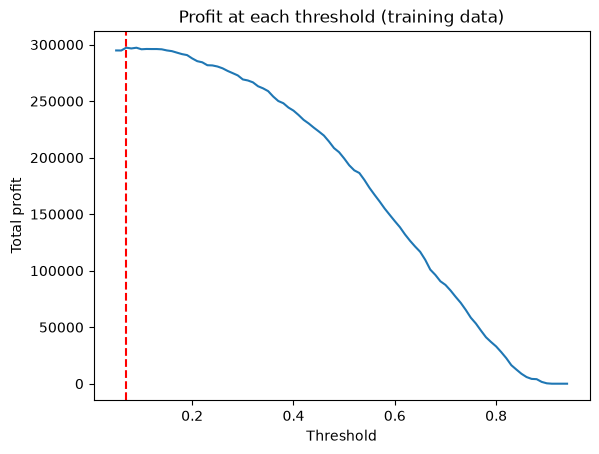

In [23]:
# ---- BUSINESS ASSUMPTIONS (edit these; state them in your write-up) ----
save_rate = 0.30          # 30% of the churners we contact are actually retained
retention_months = 12     # a saved customer keeps paying for 12 more months
offer_cost = 25.0         # cost of the retention offer per customer contacted
# -------------------------------------------------------------------------

monthly_bill = X_train['MonthlyCharges'].values
value_if_saved = save_rate * monthly_bill * retention_months   # expected money kept per real churner contacted
y_arr = y_train.values

def total_profit(scores, actual, value, threshold, cost):
    contact = scores >= threshold          # True = we send the offer
    profit_each = actual * value - cost    # churner: value minus cost; non-churner: just the cost
    return (contact * profit_each).sum()

thresholds = np.arange(0.05, 0.95, 0.01)
profits = [total_profit(train_proba, y_arr, value_if_saved, t, offer_cost) for t in thresholds]
best_t = thresholds[np.argmax(profits)]

contacted = train_proba >= best_t
print(f"Best threshold: {best_t:.2f} | profit: {max(profits):,.0f}")
print(f"Profit at 0.50: {total_profit(train_proba, y_arr, value_if_saved, 0.5, offer_cost):,.0f}")
print(f"Contact everyone: {total_profit(train_proba, y_arr, value_if_saved, 0, offer_cost):,.0f} | contact no one: 0")
print(f"Customers contacted: {contacted.mean():.1%} | precision: {y_arr[contacted].mean():.2f} | recall: {contacted[y_arr == 1].mean():.2f}")

plt.plot(thresholds, profits)
plt.axvline(best_t, color='red', linestyle='--')
plt.xlabel("Threshold"); plt.ylabel("Total profit"); plt.title("Profit at each threshold (training data)")
plt.show()

In [24]:
rows = []
for cost in [25, 50, 100, 150]:
    profits_c = [total_profit(train_proba, y_arr, value_if_saved, t, cost) for t in thresholds]
    best_c = thresholds[np.argmax(profits_c)]
    everyone = total_profit(train_proba, y_arr, value_if_saved, 0, cost)
    rows.append({'offer_cost': cost,
                 'best_threshold': round(best_c, 2),
                 'customers_contacted_%': round((train_proba >= best_c).mean() * 100, 1),
                 'model_profit': round(max(profits_c)),
                 'contact_everyone_profit': round(everyone)})
pd.DataFrame(rows)

,offer_cost,best_threshold,customers_contacted_%,model_profit,contact_everyone_profit
0,25,0.07,67.6,297286,262047
1,50,0.19,49.3,221365,121197
2,100,0.40,28.7,120267,-160503
3,150,0.53,19.2,51164,-442203


In [25]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

final_model = best_pipe    # RandomizedSearchCV already retrained it on ALL training data (refit=True)
test_scores = final_model.predict_proba(X_test)[:, 1]
test_proba = calibrator.predict_proba(to_logit(test_scores))[:, 1]
test_value = save_rate * X_test['MonthlyCharges'].values * retention_months

print("Test ROC-AUC:", round(roc_auc_score(y_test, test_proba), 3))
print("Test PR-AUC: ", round(average_precision_score(y_test, test_proba), 3))
print(classification_report(y_test, test_proba >= best_t, digits=3))
print(confusion_matrix(y_test, test_proba >= best_t))

y_test_arr = y_test.values
print(f"Test profit at {best_t:.2f}: {total_profit(test_proba, y_test_arr, test_value, best_t, offer_cost):,.0f}")
print(f"Test profit at 0.50: {total_profit(test_proba, y_test_arr, test_value, 0.5, offer_cost):,.0f}")
print(f"Test profit, contact everyone: {total_profit(test_proba, y_test_arr, test_value, 0, offer_cost):,.0f}")

Test ROC-AUC: 0.846
Test PR-AUC:  0.664
              precision    recall  f1-score   support

           0      0.973     0.423     0.590      1035
           1      0.377     0.968     0.543       374

    accuracy                          0.568      1409
   macro avg      0.675     0.696     0.567      1409
weighted avg      0.815     0.568     0.577      1409

[[438 597]
 [ 12 362]]
Test profit at 0.07: 71,598
Test profit at 0.50: 46,413
Test profit, contact everyone: 62,749


In [26]:
lift = pd.DataFrame({'proba': test_proba, 'churned': y_test.values})
lift['risk_group'] = pd.qcut(lift['proba'].rank(method='first', ascending=False), 10, labels=range(1, 11)).astype(int)  # 1 = highest risk

table = lift.groupby('risk_group').agg(Customers=('churned', 'size'),
                                       Churners=('churned', 'sum'),
                                       Churn_Rate=('churned', 'mean'))
table['Lift'] = table['Churn_Rate'] / y_test.mean()
table['Cumulative_Capture_%'] = table['Churners'].cumsum() / table['Churners'].sum() * 100
table.round(3)

,Customers,Churners,Churn_Rate,Lift,Cumulative_Capture_%
risk_group,,,,,
1,141,107,0.759,2.859,28.610
2,141,79,0.560,2.111,49.733
3,141,66,0.468,1.763,67.380
4,141,40,0.284,1.069,78.075
5,141,29,0.206,0.775,85.829
6,140,27,0.193,0.727,93.048
7,141,15,0.106,0.401,97.059
8,141,9,0.064,0.240,99.465
9,141,0,0.000,0.000,99.465


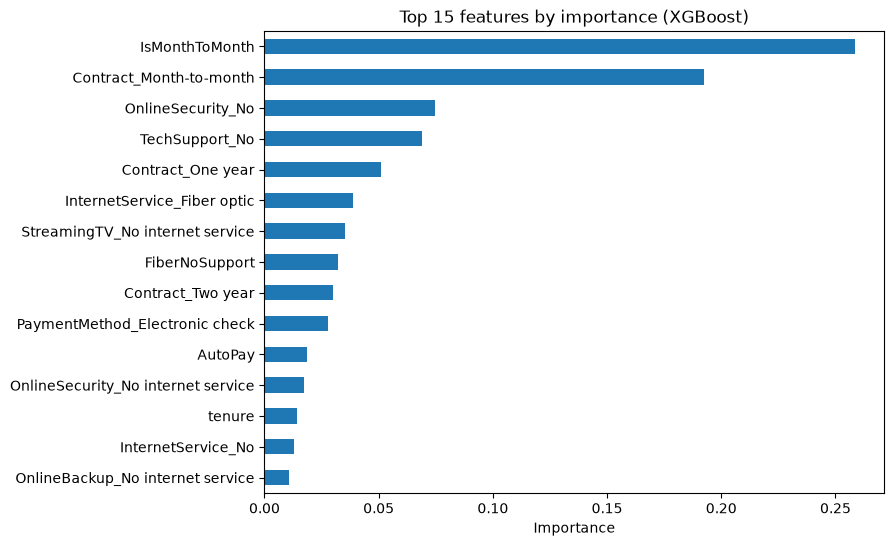

IsMonthToMonth                        0.259
Contract_Month-to-month               0.193
OnlineSecurity_No                     0.075
TechSupport_No                        0.069
Contract_One year                     0.051
InternetService_Fiber optic           0.039
StreamingTV_No internet service       0.035
FiberNoSupport                        0.032
Contract_Two year                     0.030
PaymentMethod_Electronic check        0.028
AutoPay                               0.018
OnlineSecurity_No internet service    0.017
tenure                                0.014
InternetService_No                    0.013
OnlineBackup_No internet service      0.011
dtype: float32

In [27]:
prep = final_model.named_steps['prep']
feature_names = [n.split('__', 1)[1] for n in prep.get_feature_names_out()]
importances = final_model.named_steps['clf'].feature_importances_

top = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)
top.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Top 15 features by importance (XGBoost)"); plt.xlabel("Importance"); plt.show()
top.round(3)

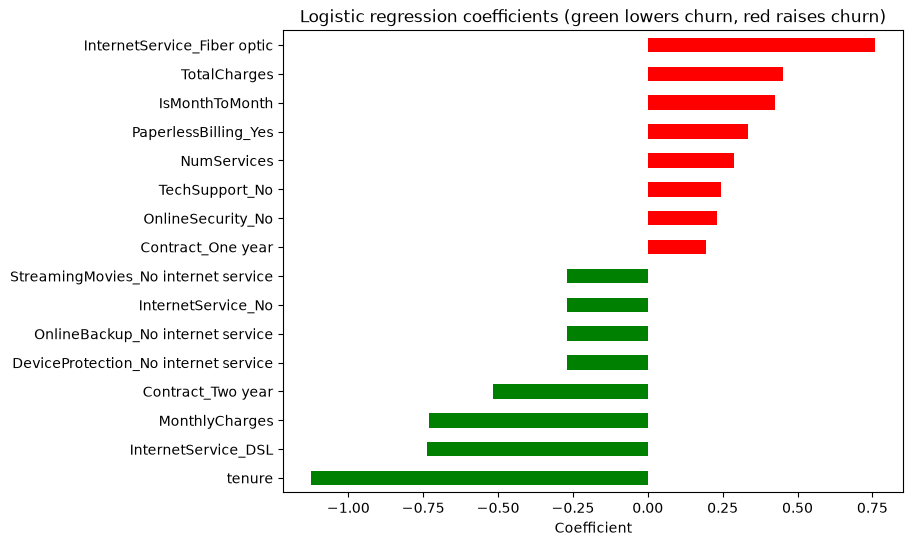

,coefficient,odds_multiplier
tenure,-1.123,0.33
InternetService_DSL,-0.736,0.48
MonthlyCharges,-0.729,0.48
Contract_Two year,-0.516,0.60
DeviceProtection_No internet service,-0.270,0.76
OnlineBackup_No internet service,-0.270,0.76
InternetService_No,-0.270,0.76
StreamingMovies_No internet service,-0.270,0.76
Contract_One year,0.194,1.21
OnlineSecurity_No,0.231,1.26


In [28]:
from sklearn.linear_model import LogisticRegression

lr_pipe = build(LogisticRegression(max_iter=1000, class_weight='balanced'))
lr_pipe.fit(X_train, y_train)

lr_names = [n.split('__', 1)[1] for n in lr_pipe.named_steps['prep'].get_feature_names_out()]
coefs = pd.Series(lr_pipe.named_steps['clf'].coef_[0], index=lr_names).sort_values()

# Top 8 features that lower churn (negative) and top 8 that raise it (positive)
extremes = pd.concat([coefs.head(8), coefs.tail(8)])
extremes.plot(kind='barh', figsize=(8, 6), color=['green'] * 8 + ['red'] * 8)
plt.title("Logistic regression coefficients (green lowers churn, red raises churn)")
plt.xlabel("Coefficient"); plt.show()

pd.DataFrame({'coefficient': extremes.round(3), 'odds_multiplier': np.exp(extremes).round(2)})

In [29]:
joblib.dump({'model': final_model, 'calibrator': calibrator, 'threshold': float(best_t)}, 'churn_model.joblib')

all_scores = final_model.predict_proba(X)[:, 1]
all_proba = calibrator.predict_proba(to_logit(all_scores))[:, 1]

scored = X.copy()
scored.insert(0, 'customerID', df['customerID'].values)
scored['Churn_Probability'] = all_proba
scored['Risk_Tier'] = np.where(all_proba >= best_t, 'High', 'Low')
scored['Annual_Revenue_At_Risk'] = all_proba * scored['MonthlyCharges'] * 12
scored.to_csv("Telecom_Churn_Scored.csv", index=False)
scored['Risk_Tier'].value_counts()

Risk_Tier
High    4776
Low     2267
Name: count, dtype: int64